<a href="https://colab.research.google.com/github/Samyuktha-77/Unsupervised/blob/main/Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_customers = pd.read_csv('/content/Mall_Customers.csv')
display(df_customers.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
features = df_customers[['Annual Income (k$)', 'Spending Score (1-100)']]
display(features.head())

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
!pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

kmedoids_mall = KMedoids(n_clusters=5, random_state=42)
kmedoids_mall.fit(features)

df_customers['Cluster'] = kmedoids_mall.labels_

print("Cluster labels:")
print(df_customers['Cluster'].value_counts())
print("\nMedoid indices:")
print(kmedoids_mall.medoid_indices_)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 19.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2114454 sha256=27ed2ec3a6c89d160dcbe0f8b70149db72166c5d4657b6ab4cb2247e664da7b6
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra
Cluster labels:
Cluster
2    60
1    46
3    39
4    33
0    22
Name: count, dtype: int64

Medoid indices:
[ 25  48  92 161 176]


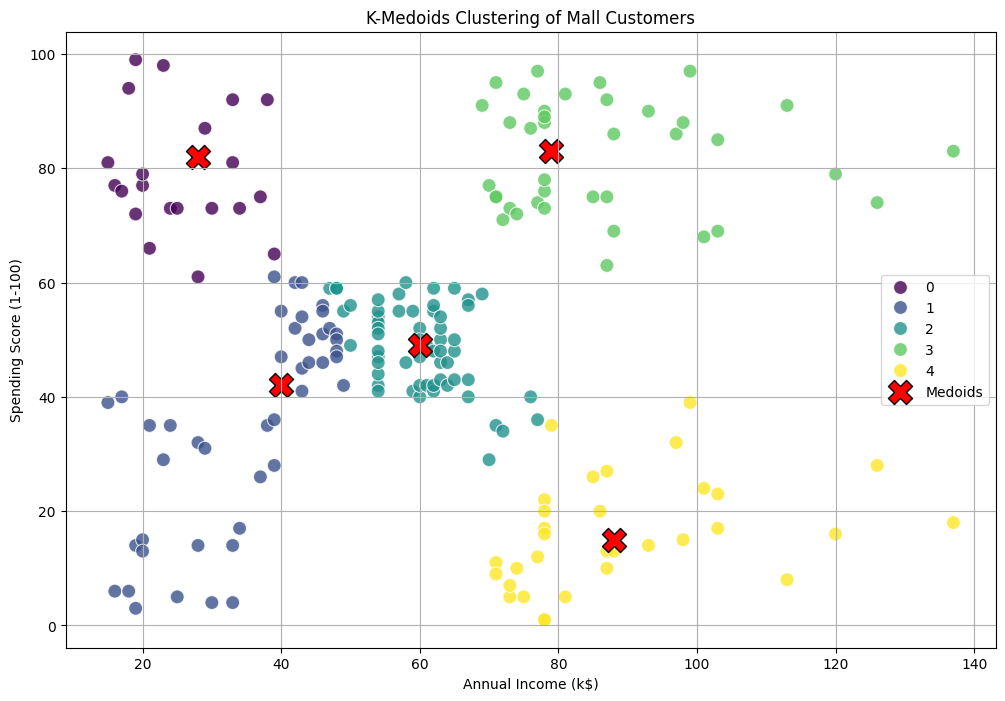

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    data=df_customers,
    legend='full',
    s=100,
    alpha=0.8
)

# Plot medoids
plt.scatter(
    features.iloc[kmedoids_mall.medoid_indices_]['Annual Income (k$)'],
    features.iloc[kmedoids_mall.medoid_indices_]['Spending Score (1-100)'],
    c='red', s=300, marker='X', label='Medoids', edgecolor='black'
)

plt.title('K-Medoids Clustering of Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend()
plt.show()